<a href="https://colab.research.google.com/github/amanatewell/flyrank-ML-internship/blob/main/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install duckdb pandas scikit-learn matplotlib seaborn huggingface-hub

In [ ]:
import os
import getpass
import duckdb

# Read HF Token securely from environment or interactive prompt
HF_TOKEN = os.getenv("HF_TOKEN") or getpass.getpass("Enter your Hugging Face Read Token: ")

# Initialize DuckDB connection
con = duckdb.connect()

# Configure DuckDB with the Hugging Face secret
con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")
con.execute(f"""
    CREATE SECRET (
        TYPE HUGGINGFACE,
        TOKEN '{HF_TOKEN}'
    );
""")

Enter your Hugging Face Read Token: ··········


In [ ]:
print(con.sql(f"DESCRIBE SELECT * FROM {FACT_TABLE} LIMIT 1").df()['column_name'].tolist())

['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta', 'ai_other', 'scroll_events', 'month']


In [19]:
import duckdb

REL = f"hf://datasets/{repo_id}"
FACT_TABLE = f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')"
DIM_CONTENT = f"read_parquet('{full_metadata_url}')"

query = f"""
WITH dataset_bounds AS (
    -- Anchor time windows to the frozen snapshot date
    SELECT MAX(report_date) AS max_date
    FROM {FACT_TABLE}
),
content_lifespan AS (
    -- Derive content age and observation window per content item
    SELECT
        content_hash_id,
        MIN(report_date) AS first_seen_date,
        MAX(report_date) AS last_seen_date
    FROM {FACT_TABLE}
    GROUP BY content_hash_id
),
aggregated_features AS (
    SELECT
        f.client_hash_id AS client_id,
        f.content_hash_id AS content_id,

        -- Overall 90-Day Search Metrics
        AVG(f.gsc_avg_position) AS avg_position,
        SUM(f.gsc_impressions) AS impressions_90d,
        SUM(f.gsc_clicks) AS clicks_90d,
        CASE
            WHEN SUM(f.gsc_impressions) > 0 THEN SUM(f.gsc_clicks) * 1.0 / SUM(f.gsc_impressions)
            ELSE 0
        END AS ctr,

        -- Engineered Behavioral Metrics
        SUM(f.ga4_sessions) AS sessions_90d,
        CASE
            WHEN SUM(f.ga4_sessions) > 0 THEN SUM(f.ga4_engaged_sessions) * 1.0 / SUM(f.ga4_sessions)
            ELSE 0
        END AS engagement_rate,
        CASE
            WHEN SUM(f.ga4_pageviews) > 0 THEN SUM(f.scroll_events) * 1.0 / SUM(f.ga4_pageviews)
            ELSE 0
        END AS scroll_rate,

        -- Traffic Channel Splits (Including AI granularity)
        SUM(f.sessions_organic) AS sessions_organic_90d,
        SUM(f.sessions_ai) AS sessions_ai_90d,
        SUM(f.ai_chatgpt) AS sessions_chatgpt_90d,
        SUM(f.ai_perplexity) AS sessions_perplexity_90d,

        -- Derived Age and Freshness
        DATE_DIFF('day', MAX(l.first_seen_date), MAX(b.max_date)) AS content_age_days,
        DATE_DIFF('day', MAX(l.last_seen_date), MAX(b.max_date)) AS days_since_last_activity,

        -- Momentum / Sub-window Traffic
        SUM(CASE WHEN f.report_date > b.max_date - INTERVAL 30 DAY THEN f.gsc_clicks ELSE 0 END) AS clicks_last_30d,
        SUM(CASE WHEN f.report_date <= b.max_date - INTERVAL 60 DAY AND f.report_date > b.max_date - INTERVAL 90 DAY THEN f.gsc_clicks ELSE 0 END) AS clicks_prev_60_90d
    FROM {FACT_TABLE} f
    CROSS JOIN dataset_bounds b
    JOIN content_lifespan l
      ON f.content_hash_id = l.content_hash_id
    LEFT JOIN {DIM_CONTENT} d
      ON f.content_hash_id = d.content_hash_id
    WHERE f.report_date > b.max_date - INTERVAL 90 DAY
    GROUP BY f.client_hash_id, f.content_hash_id
    HAVING SUM(f.gsc_impressions) >= 250
       AND DATE_DIFF('day', MAX(l.first_seen_date), MAX(b.max_date)) >= 90
)
SELECT
    *,
    -- Non-leaking decline proxy label
    CASE
        WHEN clicks_last_30d < clicks_prev_60_90d THEN 1
        ELSE 0
    END AS is_declining_label
FROM aggregated_features;
"""

print("Executing SQL feature extraction in DuckDB...")
df_features = con.sql(query).df()
print(f"Extracted feature dataset: {df_features.shape[0]:,} rows across {df_features['client_id'].nunique()} clients")
df_features.head()

Executing SQL feature extraction in DuckDB...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Extracted feature dataset: 99,633 rows across 43 clients


,client_id,content_id,avg_position,impressions_90d,clicks_90d,ctr,sessions_90d,engagement_rate,scroll_rate,sessions_organic_90d,sessions_ai_90d,sessions_chatgpt_90d,sessions_perplexity_90d,content_age_days,days_since_last_activity,clicks_last_30d,clicks_prev_60_90d,is_declining_label
0,client_0797ff3a1fc9a6a5,content_1207efddce873942,12.175899,6472.0,7.0,0.001082,NaN,0.0,0.0,NaN,NaN,NaN,NaN,237,5,5.0,0.0,0
1,client_0797ff3a1fc9a6a5,content_37952b007ab057b3,10.730421,23593.0,39.0,0.001653,NaN,0.0,0.0,NaN,NaN,NaN,NaN,237,5,25.0,7.0,0
2,client_0797ff3a1fc9a6a5,content_523abd63f061fde4,8.193221,315.0,2.0,0.006349,NaN,0.0,0.0,NaN,NaN,NaN,NaN,237,5,1.0,1.0,0
3,client_0797ff3a1fc9a6a5,content_7beb639d1052e49e,11.477134,2000.0,10.0,0.005000,NaN,0.0,0.0,NaN,NaN,NaN,NaN,237,5,5.0,4.0,0
4,client_0797ff3a1fc9a6a5,content_a08f993faabe02ea,6.280424,794.0,8.0,0.010076,NaN,0.0,0.0,NaN,NaN,NaN,NaN,237,5,8.0,0.0,0


In [23]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, precision_score

# ==========================================
# 1. DATA PREP & LEAKAGE PREVENTION
# ==========================================
# GA4 metrics have NaNs for clients without Analytics. We fill these with 0.
fill_cols = [
    'sessions_90d', 'engagement_rate', 'scroll_rate',
    'sessions_organic_90d', 'sessions_ai_90d',
    'sessions_chatgpt_90d', 'sessions_perplexity_90d'
]
df_features[fill_cols] = df_features[fill_cols].fillna(0)

# 🚨 LEAKAGE GUARD: Ensure 'clicks_last_30d', 'clicks_prev_60_90d', and the label are excluded
FEATURES = [
    'avg_position', 'impressions_90d', 'clicks_90d', 'ctr',
    'sessions_90d', 'engagement_rate', 'scroll_rate',
    'sessions_organic_90d', 'sessions_ai_90d',
    'content_age_days', 'days_since_last_activity'
]

X = df_features[FEATURES]
y = df_features['is_declining_label']
groups = df_features['client_id']

# Impute any stray NaNs (e.g., if age was missing) just in case
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=FEATURES, index=X.index)

# ==========================================
# 2. CLIENT-HOLDOUT SPLIT (GroupShuffleSplit)
# ==========================================
# This ensures 20% of CLIENTS are reserved for testing, not just random rows.
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_imputed, y, groups=groups))

X_train, X_test = X_imputed.iloc[train_idx], X_imputed.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# ==========================================
# 3. BASELINE VS. ML MODEL TRAINING
# ==========================================
# Baseline: A naive heuristic that predicts based on base class frequency
baseline_clf = DummyClassifier(strategy='prior')
baseline_clf.fit(X_train, y_train)
baseline_probas = baseline_clf.predict_proba(X_test)[:, 1]

# Actual Model: Random Forest (class_weight='balanced' handles uneven decline events)
clf = RandomForestClassifier(n_estimators=100, max_depth=6, class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)
test_probas = clf.predict_proba(X_test)[:, 1]

# ==========================================
# 4. CAPSTONE METRICS (ROC-AUC & Precision@K)
# ==========================================
roc_auc = roc_auc_score(y_test, test_probas)
baseline_roc = roc_auc_score(y_test, baseline_probas)

# Bind predictions back to the test dataframe for analysis
df_test = df_features.iloc[test_idx].copy()
df_test['decline_probability'] = test_probas
df_test_sorted = df_test.sort_values(by='decline_probability', ascending=False)

# Calculate Precision for the Top 100 recommended pages
top_100_actual = df_test_sorted.head(100)['is_declining_label']
precision_at_100 = precision_score(top_100_actual, np.ones(100))
baseline_prec_100 = y_test.mean() # What you'd get by picking 100 random URLs

print("--- CAPSTONE RESULTS ---")
print(f"Model ROC-AUC:    {roc_auc:.3f} (Baseline: {baseline_roc:.3f})")
print(f"Precision@100:    {precision_at_100:.1%} (Random Expectation: {baseline_prec_100:.1%})")

# ==========================================
# 5. ACTION ENGINE & REASON CODES
# ==========================================
def generate_reason_code(row):
    reasons = []
    if row['ctr'] < 0.02 and row['avg_position'] < 20:
        reasons.append("Meta Data: High rank, low CTR")
    if row['avg_position'] >= 20 and row['impressions_90d'] > 1000:
        reasons.append("Depth: High impressions, stalled rank")
    if row['content_age_days'] > 365:
        reasons.append("Decay: Content >1 year old")
    if row['engagement_rate'] < 0.3 and row['sessions_90d'] > 100:
        reasons.append("Intent: High traffic, low engagement")

    return " | ".join(reasons) if reasons else "General momentum drop"

df_test_sorted['action_reason_code'] = df_test_sorted.apply(generate_reason_code, axis=1)

# Export the final artifact required for the lane
export_cols = [
    'client_id', 'content_id', 'decline_probability', 'action_reason_code',
    'is_declining_label', 'clicks_90d', 'avg_position', 'sessions_chatgpt_90d'
]

final_queue = df_test_sorted[export_cols].head(500)
final_queue.to_csv("refresh_opportunity_queue.csv", index=False)

print("\n✅ Saved top 500 actionable recommendations to refresh_opportunity_queue.csv")

--- CAPSTONE RESULTS ---
Model ROC-AUC:    0.664 (Baseline: 0.500)
Precision@100:    59.0% (Random Expectation: 28.8%)

✅ Saved top 500 actionable recommendations to refresh_opportunity_queue.csv


/tmp/ipykernel_4565/4149989360.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')


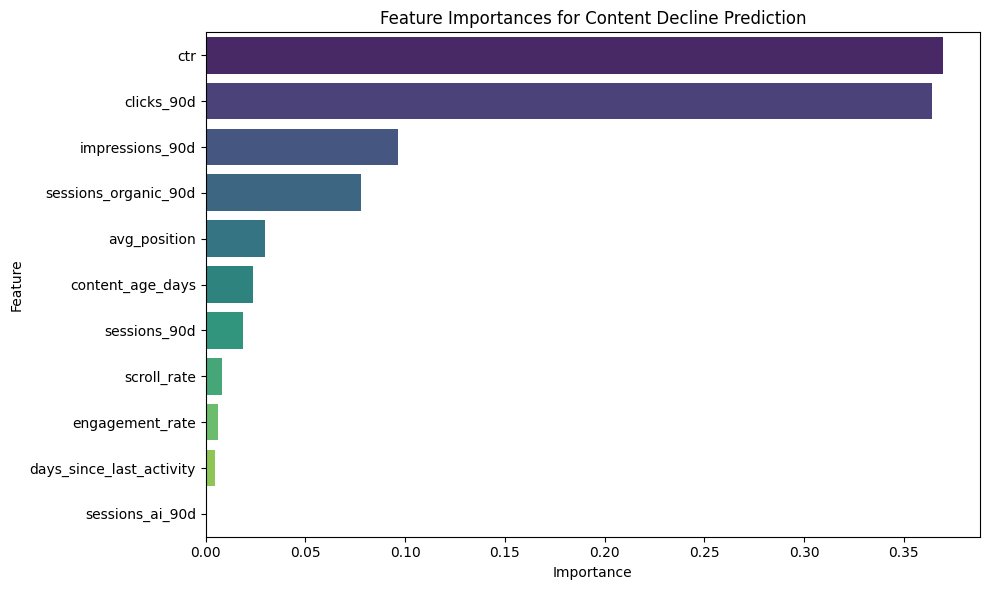

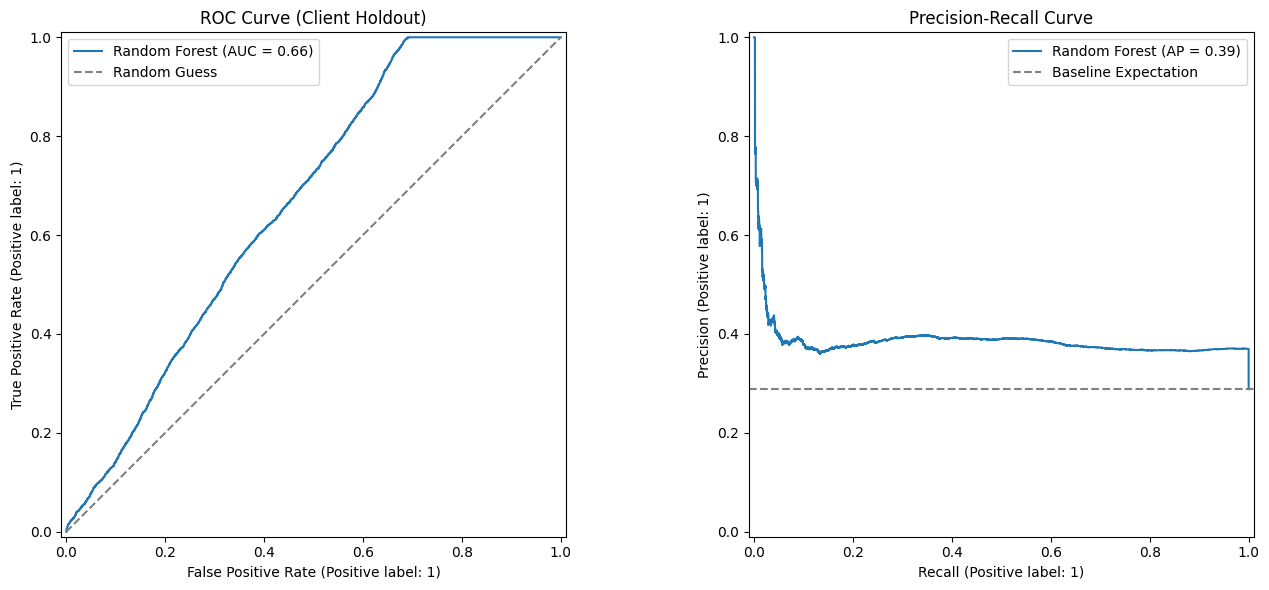

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

# 1. Plot Feature Importances
importances = clf.feature_importances_
feature_names = FEATURES

feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
plt.title('Feature Importances for Content Decline Prediction')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# 2. Plot ROC and Precision-Recall Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

RocCurveDisplay.from_estimator(clf, X_test, y_test, ax=ax1, name='Random Forest')
ax1.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
ax1.set_title('ROC Curve (Client Holdout)')
ax1.legend()

PrecisionRecallDisplay.from_estimator(clf, X_test, y_test, ax=ax2, name='Random Forest')
ax2.axhline(y=baseline_prec_100, color='gray', linestyle='--', label='Baseline Expectation')
ax2.set_title('Precision-Recall Curve')
ax2.legend()

plt.tight_layout()
plt.savefig('model_evaluation_curves.png')
plt.show()